In [51]:
# Imports.
import numpy as np;
import xarray as xr;
import matplotlib.pyplot as plt;
import h5_reader_xr as reader;
import gysela_utilities as gys_utils;
import phi2D_utilities as utils;

# Styling.
plt.style.use("ggplot");

In [52]:
# Test inputs - delete when done!
directory_path = "/zhisongqu_data/seth/GYSELA/raw/batch_10/DN_RHTEST_A3_QUIESCENT_CANONICAL"
data_arrays = reader.fetch_phi2D_data(directory_path, dataset = "Phithphi", dimensions = ["phi", "zeta", "theta"], parallelise = True);

Found 2001 files in the directory. Loading with 16 workers...


[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    4.4s
[Parallel(n_jobs=16)]: Done 352 tasks      | elapsed:    5.1s


Finished compiling data from all files in the directory.


[Parallel(n_jobs=16)]: Done 2001 out of 2001 | elapsed:    8.0s finished


In [53]:
def extract_fourier_modes(phi2D_list, dt_diag):

	time_series = xr.concat(phi2D_list, dim = "time").transpose("time", "theta", "phi");
	n_theta = time_series.sizes["theta"];
	n_phi = time_series.sizes["phi"];
	# For a theta transform, we normalise by 1/n_theta. For a phi transform, we similarly normalise by 1/n_phi.
	# When transforming in 2D, we normalise by the product of both mesh lengths.
	mesh_normalisation = n_theta * n_phi;
	fourier_sum = np.fft.fft2(time_series.values) / mesh_normalisation;
	# Unfortunately, the ordering of the Fourier modes is a bit bungled. For positive modes we are fine, but...
	# ...negative modes are ordered in reverse. We supply the grid spacing via `d`, reorder via fftshift.
	fourier_sum = np.fft.fftshift(fourier_sum, axes = (-2, -1));
	m_modes = np.fft.fftshift(np.fft.fftfreq(n_theta, d = 1 / n_theta)).astype(int);
	n_modes = np.fft.fftshift(np.fft.fftfreq(n_phi, d = 1/n_phi)).astype(int);
	amplitudes = xr.DataArray(
		# NB: taking the absolute value here kills phase information.
		np.abs(fourier_sum),
		dims = ("time", "m", "n"),
		coords = {"time": time_series.time * dt_diag, "m": m_modes, "n": n_modes}
	);
	return amplitudes;

def select_modes(amplitudes, m_range = None, n_range = None, kill_m_0 = False, kill_n_0 = False):

	if m_range is not None:
		# NB: * is the unpacking operator, so we are unpacking the tuple into the slice function.
		# So in effect, this is equivalent to amplitudes.sel(m = slice(m_range[0], m_range[1])).
		amplitudes = amplitudes.sel(m = slice(*m_range));
	
	if n_range is not None:
		amplitudes = amplitudes.sel(n = slice(*n_range));
	
	if kill_m_0:
		# This kills zonal modes.
		amplitudes = amplitudes.where(amplitudes.m != 0, drop = True);

	if kill_n_0:
		# This kills poloidally axisymmetric modes.
		amplitudes = amplitudes.where(amplitudes.n != 0, drop = True);
	
	return amplitudes;

def plot_modes(amplitudes, m_range, n_range, title_suffix = "", kill_m_0 = False, kill_n_0 = False):

	amplitudes = select_modes(amplitudes, m_range, n_range, kill_m_0 = kill_m_0, kill_n_0 = kill_n_0);
	amplitudes_stacked = amplitudes.stack(mode = ("m", "n"));

	_, ax = plt.subplots(figsize = (10, 5));
	modes = amplitudes_stacked.mode.values;
	colour_map = plt.get_cmap("turbo");

	for index, mode in enumerate(modes):

		m, n = mode;
		mode_series = amplitudes_stacked.sel(mode = mode);
		# Cycle between colours - intensities and hues actually correlate to increasing m, n, so this is super useful.
		ax.semilogy(mode_series.time, mode_series.values, label = f"m = {m}, n = {n}", color = colour_map(index / max(1, len(modes) - 1)));

	ax.set_xlabel("time [GYSELA code units]");
	ax.set_ylabel(r"$|{\Phi}_{mn}|$");
	ax.set_title(r"$|\Phi_{mn}|$ evolution, radially-averaged, " + title_suffix);
	ax.legend(bbox_to_anchor = (0, -0.15), ncol = 8, fontsize = 6, loc="upper left", frameon = True, shadow = True, fancybox = True);
	ax.grid(True, which = "both", alpha = 0.3);

def plot_all_modes(amplitudes, title_suffix):
	# Refrain from using this, unless you like spaghetti.
	_, ax = plt.subplots(figsize = (10, 5));
	amplitudes_stacked = amplitudes.stack(mode = ("m", "n"));
	ax.semilogy(amplitudes_stacked.time, amplitudes_stacked.values);
	ax.set_xlabel("time [GYSELA code units]");
	ax.set_ylabel(r"$|{\Phi}_{mn}|$");
	ax.set_title(r"$|\Phi_{mn}|$ evolution, radially-averaged, " + title_suffix);
	ax.legend(fontsize = 4, loc="lower right");
	ax.grid(True, which = "both", alpha = 0.3);

In [54]:
# A collection of tuples which should prove sufficient for standard use cases.
# Listed as m_range, n_range.
broadband_case = [(-12, 12), (-12, 12)];
itg_case = [(1, 10), (1, 12)];
zonal_case = [(0, None), (0, 0)];
gam_case = [(-1, 1), (0, 0)];

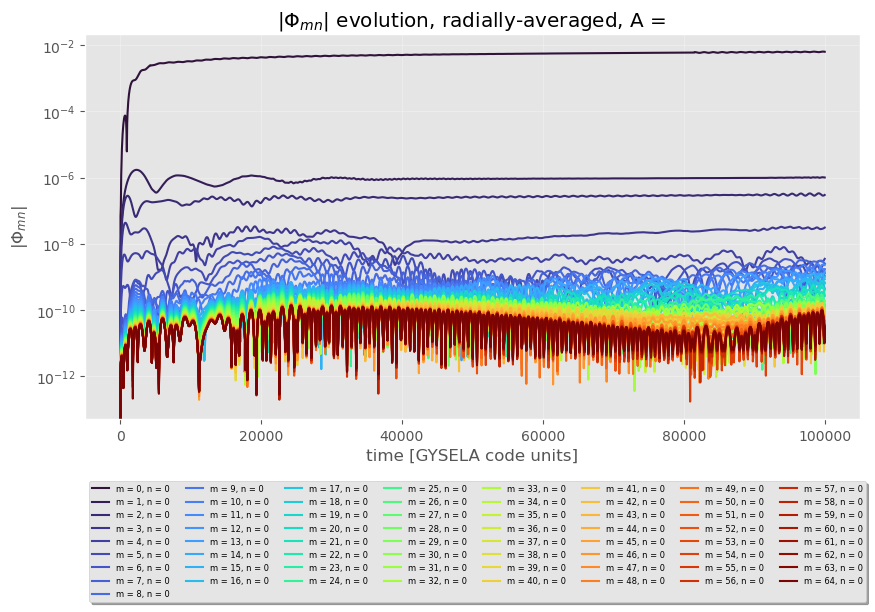

In [ ]:
mode_amplitudes = extract_fourier_modes(data_arrays, dt_diag = 50);
current_case = zonal_case;
plot_modes(mode_amplitudes, m_range = current_case[0], n_range = current_case[1], title_suffix = "A = 3, quiescent, canonical", kill_m_0 = False, kill_n_0 = False);